### 1: Imports

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import LeaveOneGroupOut
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))

### 2: Load Data

In [5]:
data_path = os.path.join(BASE_DIR, 'processed_data.csv')
df = pd.read_csv(data_path)

feature_cols = [col for col in df.columns if col not in ['pain_level', 'person_id']]
input_size = len(feature_cols)
people_ids = df['person_id'].unique()

print(f"Total windows: {len(df)}")
print(f"People: {people_ids}")
print(f"Features: {input_size}")
print(f"\nClass balance:")
print(df.groupby(['person_id', 'pain_level']).size().unstack(fill_value=0))

Total windows: 1058
People: [0 1 2]
Features: 15

Class balance:
pain_level   0    1   2   3
person_id                  
0           71   84  83  83
1           84  144  84  75
2           83  114  73  80


### 3: helper funcs

In [6]:
def augment_data(df, feature_cols, n_copies=5, noise_std=0.05):
    augmented = [df.copy()]
    for _ in range(n_copies):
        copy = df.copy()
        noise = np.random.normal(0, noise_std, size=copy[feature_cols].shape)
        copy[feature_cols] = copy[feature_cols] + noise
        augmented.append(copy)
    return pd.concat(augmented, ignore_index=True)

def plot_confusion_matrix(true, pred, title, num_classes=4):
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Level {i}' for i in range(num_classes)],
                yticklabels=[f'Level {i}' for i in range(num_classes)])
    plt.title(title)
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

### 4: SVM LOOCV

Person accuracy: 39.25%
Person accuracy: 29.20%
Person accuracy: 36.29%

SVM LOOCV Accuracy: 34.91%


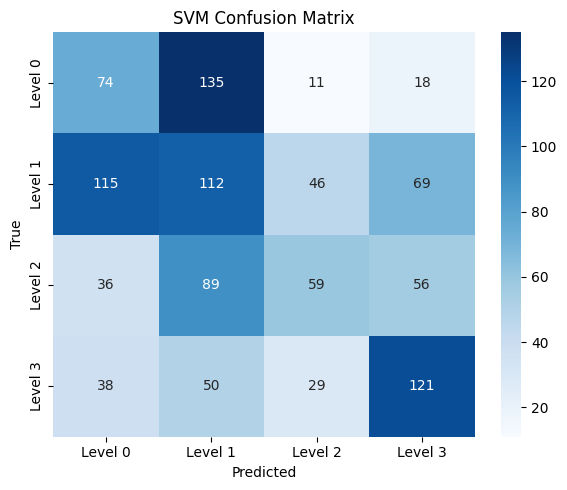

In [7]:
logo = LeaveOneGroupOut()
X = df[feature_cols].values
y = df['pain_level'].values.astype(int)
groups = df['person_id'].values

svm_scores = []
svm_true = []
svm_pred = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    svm = SVC(kernel='rbf', C=5, gamma='scale')
    svm.fit(X_train, y_train)
    preds = svm.predict(X_test)

    acc = accuracy_score(y_test, preds) * 100
    svm_scores.append(acc)
    svm_true.extend(y_test.tolist())
    svm_pred.extend(preds.tolist())
    print(f"Person accuracy: {acc:.2f}%")

print(f"\nSVM LOOCV Accuracy: {np.mean(svm_scores):.2f}%")
plot_confusion_matrix(svm_true, svm_pred, "SVM Confusion Matrix")

### 5: XGBoost

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
xgb_scores = []
xgb_true = []
xgb_pred = []

for train_idx, test_idx in logo.split(X, y, groups):
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        eval_metric='mlogloss',
        verbosity=0
    )
    weights = compute_sample_weight('balanced', y_train)
    model.fit(X_train, y_train, sample_weight=weights)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds) * 100
    xgb_scores.append(acc)
    xgb_true.extend(y_test.tolist())
    xgb_pred.extend(preds.tolist())
    print(f"Person accuracy: {acc:.2f}%")

print(f"\nXGBoost LOOCV Accuracy: {np.mean(xgb_scores):.2f}%")
plot_confusion_matrix(xgb_true, xgb_pred, "XGBoost Confusion Matrix")

: 

### 6: pytorch

In [ ]:
class PainDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        labels = y.copy().astype(int)
        if labels.min() == 1:
            labels = labels - 1
        self.y = torch.tensor(labels, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        features = self.X[idx]
        if self.augment:
            features = features + torch.randn_like(features) * 0.01
        return features, self.y[idx]

class PainTrackerMLP(nn.Module):
    def __init__(self, input_size, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

EPOCHS = 50
BATCH_SIZE = 16
LR = 0.001
NUM_CLASSES = 4

### 7: MLP LOOCV

In [ ]:
mlp_scores = []
mlp_true = []
mlp_pred = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    train_loader = DataLoader(
        PainDataset(X_train, y_train, augment=True),
        batch_size=BATCH_SIZE, shuffle=True
    )
    test_loader = DataLoader(
        PainDataset(X_test, y_test, augment=False),
        batch_size=BATCH_SIZE, shuffle=False
    )

    model = PainTrackerMLP(input_size=input_size, num_classes=NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    loss_history = []
    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0
        for bX, by in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(bX), by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(train_loader)
        loss_history.append(avg)
        scheduler.step(avg)

    model.eval()
    correct, total = 0, 0
    fold_true, fold_pred = [], []
    with torch.no_grad():
        for bX, by in test_loader:
            _, predicted = torch.max(model(bX), 1)
            total += by.size(0)
            correct += (predicted == by).sum().item()
            fold_true.extend(by.tolist())
            fold_pred.extend(predicted.tolist())

    acc = 100 * correct / total if total > 0 else 0
    mlp_scores.append(acc)
    mlp_true.extend(fold_true)
    mlp_pred.extend(fold_pred)
    print(f"Person accuracy: {acc:.2f}%")

print(f"\nMLP LOOCV Accuracy: {np.mean(mlp_scores):.2f}%")
plot_confusion_matrix(mlp_true, mlp_pred, "MLP Confusion Matrix")

### 8: compare

--- Fold: Testing on Person 0 ---


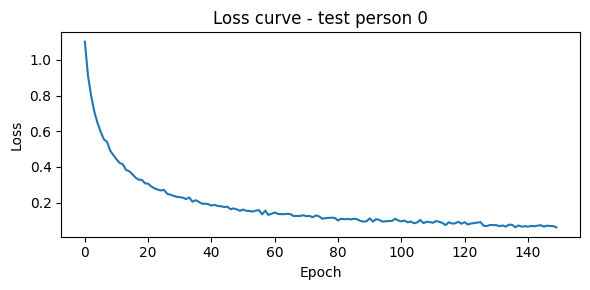

Person 0 accuracy: 41.43%

--- Fold: Testing on Person 1 ---


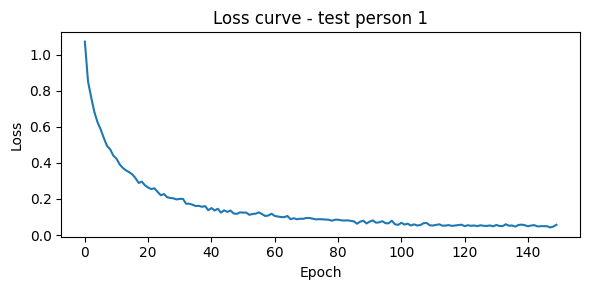

Person 1 accuracy: 36.69%

--- Fold: Testing on Person 2 ---


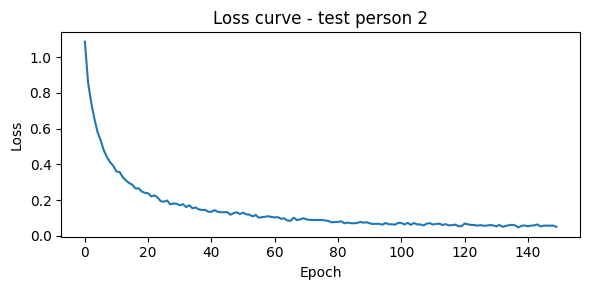

Person 2 accuracy: 33.14%

Average LOOCV Accuracy: 37.09%


In [ ]:
print("========= Model Comparison =========")
print(f"SVM:     {np.mean(svm_scores):.2f}%")
print(f"XGBoost: {np.mean(xgb_scores):.2f}%")
print(f"MLP:     {np.mean(mlp_scores):.2f}%")
print("====================================")

### 9: save best model

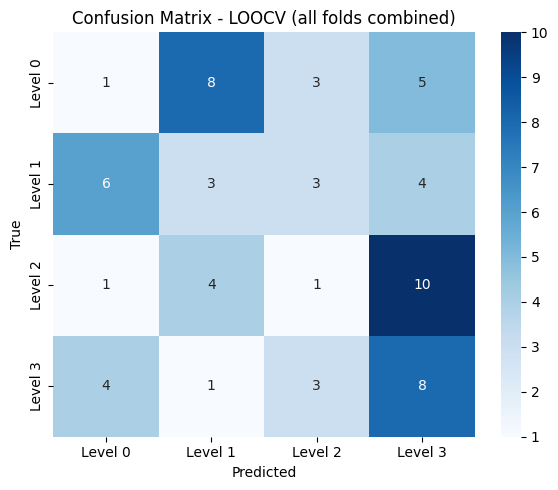

In [ ]:
final_scaler = StandardScaler()
X_all = final_scaler.fit_transform(X)

best_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    eval_metric='mlogloss',
    verbosity=0
)
best_model.fit(X_all, y)

best_model.save_model(os.path.join(BASE_DIR, 'base_model.json'))
joblib.dump(final_scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
print("base_model.json and scaler.pkl saved.")